# Analysis of a CFIS shear catalogue
First steps.

In [25]:
import numpy as np

from astropy.io import fits
import matplotlib.pylab as plt

import treecorr

%matplotlib inline

## Open FITS file

In [9]:
cat_name = 'shape_catalog_ngmix.fits'
hdu = fits.open(cat_name)
data = hdu[1].data

In [4]:
# Print column names
data.dtype.names

('ra', 'dec', 'g1', 'g2', 'w', 'mag', 'snr', 'g1_uncal', 'g2_uncal')

In [6]:
# Print header
hdu[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   72 / length of dimension 1                          
NAXIS2  =              2229653 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    9 / number of table fields                         
TTYPE1  = 'ra      '                                                            
TFORM1  = 'D       '                                                            
TUNIT1  = 'deg     '                                                            
TTYPE2  = 'dec     '                                                            
TFORM2  = 'D       '        

## Plot spatial distribution

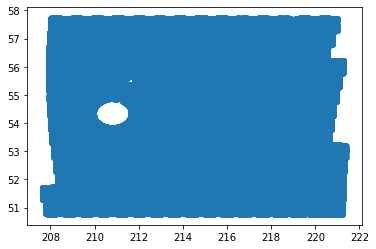

In [12]:
_ = plt.plot(data['ra'], data['dec'], '.')

## Compute shear-shear correlation

In [16]:
# Create TreeCorr configuration

sep_units = 'arcmin'

TreeCorrConfig = {
        'ra_units': 'degrees',
        'dec_units': 'degrees',
        'max_sep': '200',
        'min_sep': '0.1',
        'sep_units': sep_units,
        'nbins': 20
    }

In [17]:
# Create TreeCorr catalogue

cat_gal = treecorr.Catalog(
    ra=data['ra'],
    dec=data['dec'],
    g1=data['g1'],
    g2=data['g2'],
    w=data['w'],
    ra_units='degrees',
    dec_units='degrees'
)

In [18]:
# Create and process correlation object

gg = treecorr.GGCorrelation(TreeCorrConfig)

gg.process(cat_gal, cat_gal)

## Plot shear correlation functions.
Error bars are computed by treecorr, and are here shape/shot noise only.

In [22]:
gg.xi

GGCorrelation(config={'max_sep': 200.0, 'min_sep': 0.1, 'sep_units': 'arcmin', 'nbins': 20, 'brute': False, 'verbose': 1, 'split_method': 'mean', 'max_top': 10, 'precision': 4, 'pairwise': False, 'm2_uform': 'Crittenden', 'metric': 'Euclidean', 'bin_type': 'Log', 'var_method': 'shot', 'num_bootstrap': 500})

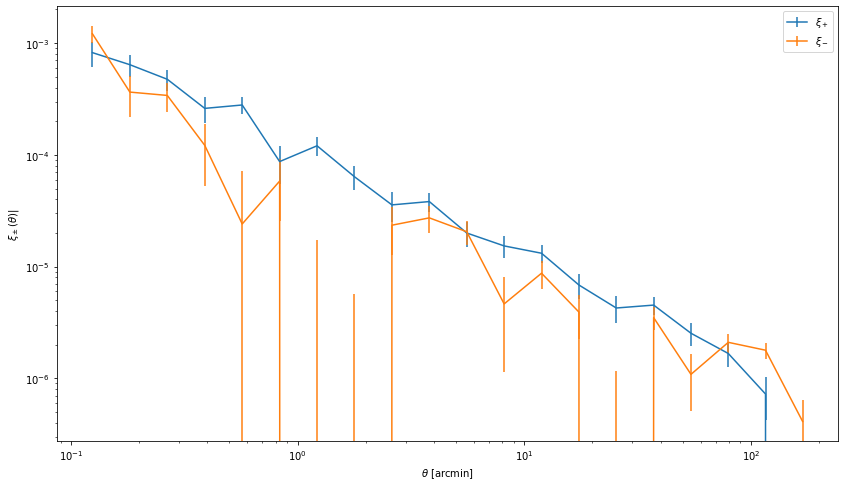

In [43]:
plt.figure(figsize=(14,8))

plt.errorbar(gg.meanr, gg.xip, yerr=np.sqrt(gg.varxip), label=r'$\xi_+$')
plt.errorbar(gg.meanr, gg.xim, yerr=np.sqrt(gg.varxim), label=r'$\xi_-$')
plt.loglog()

plt.legend()
plt.xlabel(rf'$\theta$ [{sep_units}]')
_ = plt.ylabel(r'$\xi_\pm(\theta)$')